In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [15]:
df = pd.read_csv("heart_ecg.csv")
print(df.shape)
print(df.head())

(58726, 188)
   signal_1  signal_2  signal_3  signal_4  signal_5  signal_6  signal_7  \
0       1.0  0.698745  0.012552  0.012552  0.150628  0.133891  0.071130   
1       1.0  0.350290  0.024469  0.065035  0.141017  0.225370  0.250483   
2       1.0  0.945055  0.611722  0.260073  0.150183  0.124542  0.084249   
3       1.0  0.897275  0.232704  0.023061  0.079665  0.153040  0.136268   
4       1.0  0.950637  0.735669  0.544586  0.530255  0.565287  0.565287   

   signal_8  signal_9  signal_10  ...  signal_179  signal_180  signal_181  \
0  0.062762  0.066946   0.071130  ...         0.0         0.0         0.0   
1  0.238892  0.237605   0.238249  ...         0.0         0.0         0.0   
2  0.087912  0.069597   0.069597  ...         0.0         0.0         0.0   
3  0.140461  0.129979   0.121593  ...         0.0         0.0         0.0   
4  0.565287  0.554140   0.557325  ...         0.0         0.0         0.0   

   signal_182  signal_183  signal_184  signal_185  signal_186  signal_187

In [16]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [17]:
df.iloc[:, -1].value_counts(normalize=True)


,proportion
label,
0,0.5
1,0.5


In [18]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


X = X.reshape(X.shape[0], X.shape[1], 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [22]:
model = Sequential([
    Conv1D(64, kernel_size=7, activation='relu', input_shape=(187, 1)),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(256, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [24]:
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.005),
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
735/735 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7166 - loss: 0.8331 - val_accuracy: 0.7242 - val_loss: 0.6382
Epoch 2/20
735/735 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8675 - loss: 0.3157 - val_accuracy: 0.8869 - val_loss: 0.2745
Epoch 3/20
735/735 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9154 - loss: 0.2191 - val_accuracy: 0.9286 - val_loss: 0.1970
Epoch 4/20
735/735 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9311 - loss: 0.1814 - val_accuracy: 0.9081 - val_loss: 0.2779
Epoch 5/20
735/735 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9437 - loss: 0.1477 - val_accuracy: 0.9154 - val_loss: 0.2461
Epoch 6/20
735/735 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9446 - loss: 0.1485 - val_accuracy: 0.9171 - val_loss: 0.2587
Epoch 7/20
735/735 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9554 - loss: 0.1241 - val_accuracy: 0.8983 - val_loss: 0.3951
Epoch 8/20
735/735 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9582 - loss: 0.1140 - val_accuracy: 

In [25]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

368/368 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9173 - loss: 0.4707
Test Accuracy: 0.9208


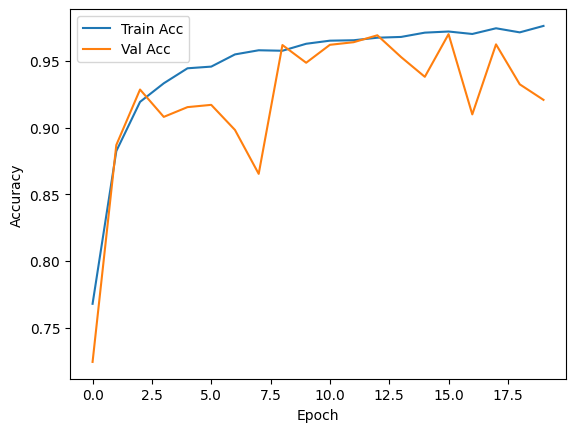

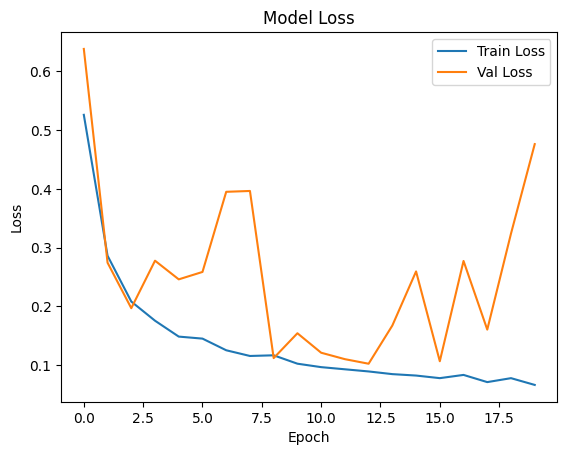

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [29]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"🧾 Test Loss: {test_loss:.4f}")

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9173 - loss: 0.4707
✅ Test Accuracy: 0.9208
🧾 Test Loss: 0.4762


In [28]:

y_pred_prob = model.predict(X_test)


y_pred = (y_pred_prob > 0.5).astype(int)


for i in range(10):
    print(f"Sample {i+1}: Predicted = {y_pred[i][0]}, Actual = {y_test[i]}")


368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Sample 1: Predicted = 1, Actual = 1
Sample 2: Predicted = 0, Actual = 0
Sample 3: Predicted = 1, Actual = 1
Sample 4: Predicted = 0, Actual = 0
Sample 5: Predicted = 1, Actual = 1
Sample 6: Predicted = 0, Actual = 0
Sample 7: Predicted = 0, Actual = 0
Sample 8: Predicted = 0, Actual = 0
Sample 9: Predicted = 0, Actual = 0
Sample 10: Predicted = 1, Actual = 1


In [31]:
from google.colab import files


model.save("heartbeat_cnn_model.h5")

files.download("heartbeat_cnn_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>